In [1]:
import numpy as np
import matplotlib.pyplot as plt
import timeit
from pathlib import Path

# Punto 1 - Muestreo de distribuciones de probabilidad

In [2]:
# Carpeta donde se guardarán los gráficos del TP.
GRAFICOS_DIR = Path("graficos")

# Creamos la carpeta si todavía no existe.
GRAFICOS_DIR.mkdir(exist_ok=True)

In [3]:
# Carpeta específica para los gráficos del punto 1.
PUNTO1_DIR = GRAFICOS_DIR / "punto1"
PUNTO1_DIR.mkdir(exist_ok=True)

In [4]:
def normal_12_uniforms(mu, sigma2):
    """
    Genera una muestra aproximada de una distribución normal N(mu, sigma2)
    sumando 12 muestras de una distribución uniforme.

    mu: media de la normal
    sigma2: varianza de la normal
    """

    # La consigna recibe la varianza, por lo que calculamos
    # el desvío estándar para escalar la muestra.
    sigma = np.sqrt(sigma2)

    # La suma de 12 uniformes U(0,1) tiene media 6 y varianza 1.
    # Restando 6 obtenemos una variable aproximadamente N(0,1).
    z = np.sum(np.random.uniform(0, 1, 12)) - 6

    # Escalamos y desplazamos para obtener N(mu, sigma2).
    return mu + sigma * z

In [5]:
def normal_rejection(mu, sigma2):
    """
    Genera una muestra de una distribución normal N(mu, sigma2)
    utilizando muestreo con rechazo.

    mu: media de la normal
    sigma2: varianza de la normal
    """

    sigma = np.sqrt(sigma2)

    while True:
        # Generamos dos muestras uniformes dentro del cuadrado [-1, 1] x [-1, 1].
        u1 = np.random.uniform(-1, 1)
        u2 = np.random.uniform(-1, 1)

        # Distancia cuadrada al origen.
        s = u1**2 + u2**2

        # Solo aceptamos puntos que estén dentro del círculo unitario.
        # También descartamos s = 0 porque aparecería una división por cero.
        if 0 < s < 1:
            z = u1 * np.sqrt(-2 * np.log(s) / s)

            return mu + sigma * z

In [6]:
def normal_box_muller(mu, sigma2):
    """
    Genera una muestra de una distribución normal N(mu, sigma2)
    utilizando la transformación de Box-Muller.

    mu: media de la normal
    sigma2: varianza de la normal
    """

    sigma = np.sqrt(sigma2)

    # Generamos las dos muestras uniformes requeridas por Box-Muller.
    u1 = np.random.uniform(0, 1)
    u2 = np.random.uniform(0, 1)

    # Evitamos log(0), ya que no está definido.
    while u2 == 0:
        u2 = np.random.uniform(0, 1)

    # Transformación de Box-Muller para obtener una N(0,1).
    z = np.cos(2 * np.pi * u1) * np.sqrt(-2 * np.log(u2))

    # Transformamos la normal estándar a N(mu, sigma2).
    return mu + sigma * z

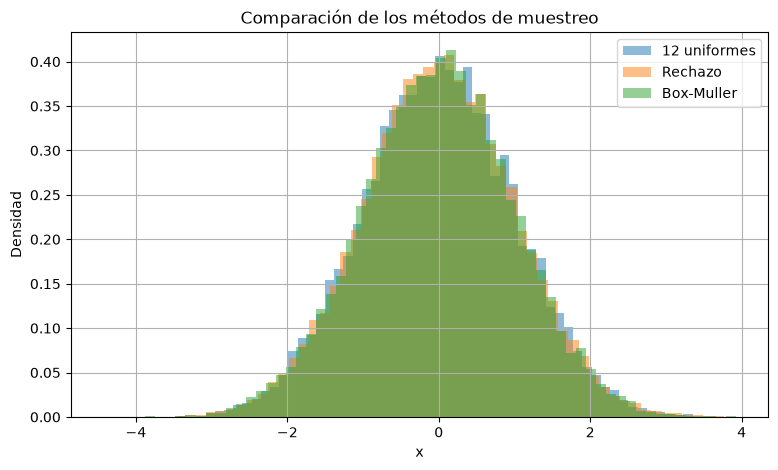

In [7]:
# Parámetros usados para probar los métodos.
mu = 0
sigma2 = 1

# Cantidad de muestras para visualizar las distribuciones.
N = 20000

samples_12 = np.array([
    normal_12_uniforms(mu, sigma2)
    for _ in range(N)
])

samples_rejection = np.array([
    normal_rejection(mu, sigma2)
    for _ in range(N)
])

samples_box_muller = np.array([
    normal_box_muller(mu, sigma2)
    for _ in range(N)
])


plt.figure(figsize=(9, 5))

plt.hist(
    samples_12,
    bins=60,
    density=True,
    alpha=0.5,
    label="12 uniformes"
)

plt.hist(
    samples_rejection,
    bins=60,
    density=True,
    alpha=0.5,
    label="Rechazo"
)

plt.hist(
    samples_box_muller,
    bins=60,
    density=True,
    alpha=0.5,
    label="Box-Muller"
)

plt.xlabel("x")
plt.ylabel("Densidad")
plt.title("Comparación de los métodos de muestreo")
plt.legend()
plt.grid()

plt.savefig(
    PUNTO1_DIR / "distribuciones.jpg",
    dpi=300,
    bbox_inches="tight"
)

In [8]:
print("12 uniformes:")
print("Media:", np.mean(samples_12))
print("Varianza:", np.var(samples_12))

print("\nRechazo:")
print("Media:", np.mean(samples_rejection))
print("Varianza:", np.var(samples_rejection))

print("\nBox-Muller:")
print("Media:", np.mean(samples_box_muller))
print("Varianza:", np.var(samples_box_muller))

12 uniformes:
Media: 0.0013673297749726644
Varianza: 0.9893822727350969

Rechazo:
Media: 0.0012478187507536304
Varianza: 0.9940835254142206

Box-Muller:
Media: -0.005237389879002324
Varianza: 0.9916197580135284


In [9]:
# Parámetros de la normal utilizada para comparar tiempos.
mu = 0
sigma2 = 1
sigma = np.sqrt(sigma2)

# Cantidad de muestras que generará cada método.
N = 100000


# Medimos el tiempo total de generación de N muestras.
time_12 = timeit.timeit(
    lambda: normal_12_uniforms(mu, sigma2),
    number=N
)

time_rejection = timeit.timeit(
    lambda: normal_rejection(mu, sigma2),
    number=N
)

time_box_muller = timeit.timeit(
    lambda: normal_box_muller(mu, sigma2),
    number=N
)

# numpy.random.normal recibe el desvío estándar y no la varianza.
time_numpy = timeit.timeit(
    lambda: np.random.normal(mu, sigma),
    number=N
)


print(f"12 uniformes:       {time_12:.4f} s")
print(f"Muestreo rechazo:   {time_rejection:.4f} s")
print(f"Box-Muller:         {time_box_muller:.4f} s")
print(f"numpy.random.normal:{time_numpy:.4f} s")

12 uniformes:       0.9035 s
Muestreo rechazo:   1.0540 s
Box-Muller:         0.8761 s
numpy.random.normal:0.1242 s


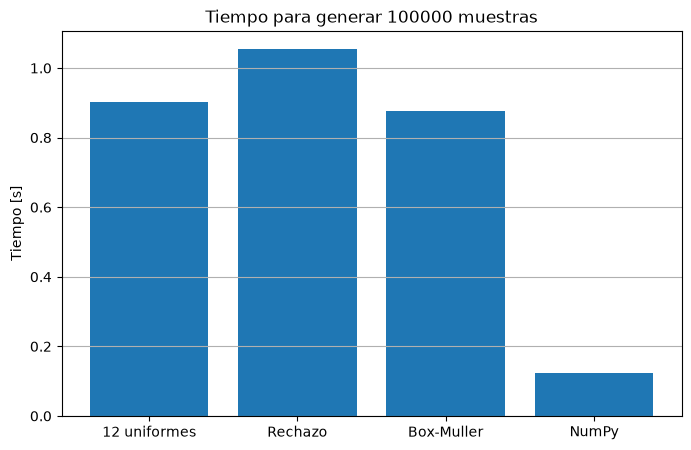

In [10]:
methods = [
    "12 uniformes",
    "Rechazo",
    "Box-Muller",
    "NumPy"
]

times = [
    time_12,
    time_rejection,
    time_box_muller,
    time_numpy
]


plt.figure(figsize=(8, 5))

plt.bar(methods, times)

plt.ylabel("Tiempo [s]")
plt.title(f"Tiempo para generar {N} muestras")
plt.grid(axis="y")

plt.savefig(
    PUNTO1_DIR / "tiempos.jpg",
    dpi=300,
    bbox_inches="tight"
)

### Comparación de tiempos

Para 100000 muestras, numpy.random.normal fue el método más rápido. Entre las funciones implementadas, Box-Muller tuvo el menor tiempo de ejecución, seguido por el método de las 12 uniformes, mientras que el muestreo con rechazo fue el más lento. Esto tiene sentido porque el método con rechazo puede necesitar generar más de una pareja de valores uniformes antes de aceptar una muestra.